In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("movies.csv")

print(df.head())

      budget    revenue  popularity  runtime  vote_average    title  \
0   57755036  107323371   60.377360       98      6.611888  Movie 1   
1  192100010  342896533   86.289857       96      7.184687  Movie 2   
2  128521863  253206827   86.995324      148      3.542978  Movie 3   
3  156299516   89635602   72.710096      118      5.985176  Movie 4   
4  148532820  221133868   74.829585      161      4.578480  Movie 5   

                               genres  
0  [{'id': 10749, 'name': 'Romance'}]  
1       [{'id': 18, 'name': 'Drama'}]  
2      [{'id': 35, 'name': 'Comedy'}]  
3       [{'id': 18, 'name': 'Drama'}]  
4      [{'id': 35, 'name': 'Comedy'}]  


In [3]:
# Check Dataset Shape
print(df.shape)

(2000, 7)


In [4]:
# Check Data Types
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   str    
 6   genres        2000 non-null   str    
dtypes: float64(2), int64(3), str(2)
memory usage: 185.8 KB
None


In [5]:
# Summary Statistics
print(df.describe())

             budget       revenue   popularity      runtime  vote_average
count  2.000000e+03  2.000000e+03  2000.000000  2000.000000   2000.000000
mean   1.019211e+08  1.780574e+08    50.090738   129.568000      6.036764
std    5.682795e+07  1.293879e+08    28.482104    28.906507      1.743093
min    1.070640e+06  1.138729e+06     1.018466    80.000000      3.008133
25%    5.274832e+07  7.458306e+07    25.720784   104.000000      4.583298
50%    1.026023e+08  1.484882e+08    50.210396   130.000000      6.052901
75%    1.507962e+08  2.623679e+08    74.925354   155.000000      7.577305
max    1.999879e+08  5.744901e+08    99.764659   179.000000      8.998509


In [6]:
# Check Missing Values
print(df.isnull().sum())

budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64


In [7]:
# Check Zero Budget and Revenue
print((df["budget"]==0).sum())

print((df["revenue"]==0).sum())

0
0


In [8]:
# Remove Invalid Rows
df = df[(df["budget"]>0) & (df["revenue"]>0)]

In [9]:
# Create Target Variable
df["success"]=(df["revenue"]>df["budget"]).astype(int)

In [10]:
print(df["success"].value_counts())

success
1    1614
0     386
Name: count, dtype: int64


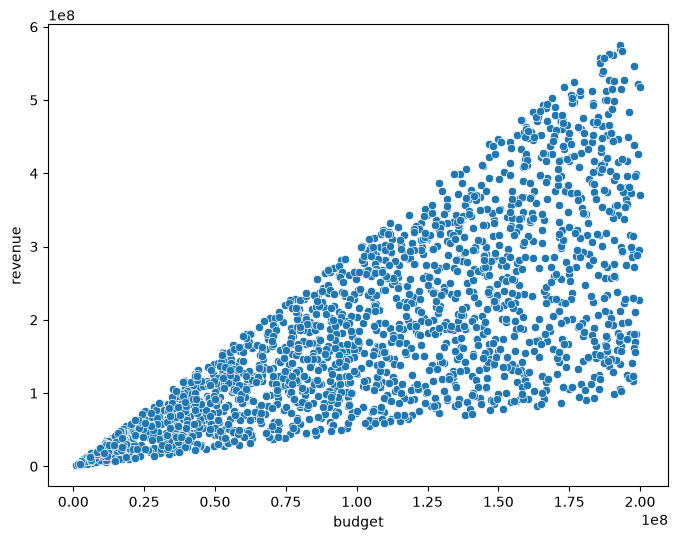

In [11]:
# Scatter Plot
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="budget",
                y="revenue")

plt.show()

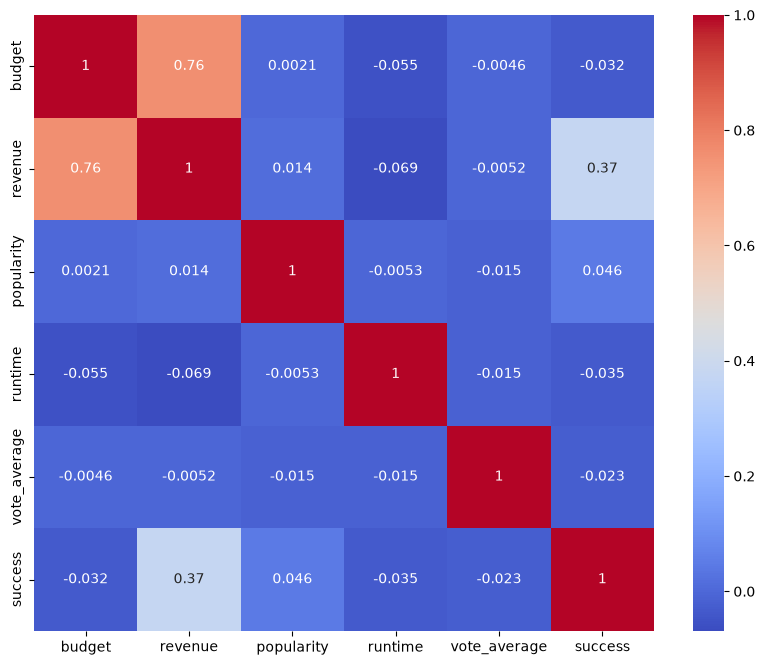

In [12]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [13]:
# Genre Analysis
df["genres"].value_counts().head(10)

genres
[{'id': 10749, 'name': 'Romance'}]          220
[{'id': 12, 'name': 'Adventure'}]           207
[{'id': 878, 'name': 'Science Fiction'}]    205
[{'id': 16, 'name': 'Animation'}]           203
[{'id': 35, 'name': 'Comedy'}]              202
[{'id': 27, 'name': 'Horror'}]              199
[{'id': 18, 'name': 'Drama'}]               197
[{'id': 53, 'name': 'Thriller'}]            194
[{'id': 28, 'name': 'Action'}]              192
[]                                          181
Name: count, dtype: int64

In [15]:
# Random Forest Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
 # Features
X=df[["budget","popularity","runtime","vote_average"]]

y=df["success"]

In [ ]:
# Split
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

In [ ]:
# Train
model=RandomForestClassifier()

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Prediction
pred=model.predict(X_test)

In [ ]:
# Accuracy
print(accuracy_score(y_test,pred))

0.785


In [ ]:
# save model
import pickle

pickle.dump(model,open("model.pkl","wb"))